# 00 — Quickstart

`QickworkspaceV2` is a self-contained automated quantum calibration framework built on QICK.  
This notebook runs entirely **offline** using `SimulatedBackend` — no hardware needed.

What you will learn:
1. Start a simulated session
2. Build a hardware config
3. Run your first experiment
4. Inspect the `ExperimentData` result

In [1]:
import sys
sys.path.insert(0, r'../')   # adjust if running from a different directory

import QickworkspaceV2
print('QickworkspaceV2', QickworkspaceV2.__version__)

QickworkspaceV2 1.0.0


## 1. Start a simulated session

`SimulatedBackend` generates realistic synthetic IQ data for every experiment type.  
Calling `.activate()` registers it as the global session so that all experiment
classes can find the mock hardware objects.

In [2]:
from QickworkspaceV2 import SimulatedBackend

backend = SimulatedBackend(noise_level=0.02)
backend.activate()   # sets BaseExperiment._soc / _soccfg globally

[SimulatedBackend] Session activated (no hardware required)


## 2. Define a minimal hardware config

In a real lab session `config_list` lives in `QickworkspaceV2/config/system_cfg.py`.
Here we build a minimal dict by hand to keep the example self-contained.

In [3]:
from QickworkspaceV2 import ExperimentConfig

raw_config = [
    {
        "name": "Q1",
        # channel assignments
        "ch": {"ro_ch": 0, "res_ch": 0, "qb_ch": 1},
        # resonator
        "res": {"res_freq_ge": 6700.0, "res_gain": 0.5, "res_length": 2.0},
        # qubit
        "qb":  {"qb_freq_ge": 5000.0, "pi_gain_ge": 0.5, "sigma": 0.025},
        # experiment defaults
        "reps": 100, "relax_delay": 300.0, "steps": 101,
        # sweep range for resonator spec
        "res_freq_ge_start": 6690.0, "res_freq_ge_stop": 6710.0,
        "kappa": 5.0,
    }
]

cfg_all = ExperimentConfig(raw_config)
cfg = cfg_all.get_qubit('Q1')
print('Flat config keys:', list(cfg.keys()))

Flat config keys: ['name', 'ro_ch', 'res_ch', 'qb_ch', 'res_freq_ge', 'res_gain', 'res_length', 'qb_freq_ge', 'pi_gain_ge', 'sigma', 'reps', 'relax_delay', 'steps', 'res_freq_ge_start', 'res_freq_ge_stop', 'kappa']


## 3. Run Resonator Spectroscopy

`ResonatorSpec` sweeps the resonator drive frequency and fits a circle (ABCD hanger model)
to extract `f0`, `κ`, and `κ_c`.

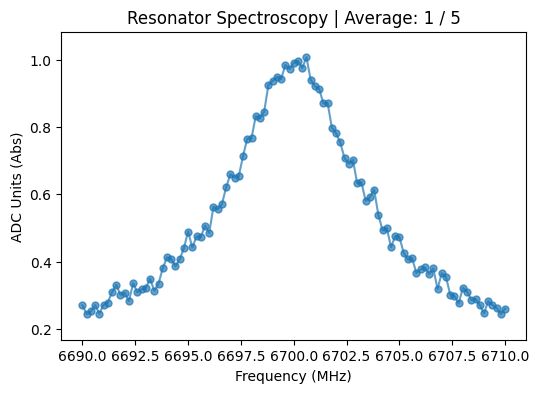

Software Average Count:   0%|          | 0/5 [00:00<?, ?it/s]

In [4]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

expt = ResonatorSpec(cfg, backend=backend)
result = expt.run(py_avg=5)

## 4. Inspect the result

`ExperimentData` is the unified return type from every experiment.  
It supports the old tuple-unpack style **and** a rich named dict.

In [5]:
from QickworkspaceV2 import QualityFlag

# New API
print('Experiment   :', result.experiment_type)
print('Quality      :', result.quality)
print('Fit result   :', result.fit_result)
print('Scalar result:', result.scalar_result)
print('x_axis shape :', result.x_axis.shape)
print('y_axis       :', result.y_axis.shape if result.y_axis is not None else 'None (1-D experiment)')

# Backward-compat tuple unpack
fit_params, fit_errors = result
print('fit_params   :', fit_params)

# Backward-compat scalar coercion
freq = float(result)
print(f'Resonator freq (scalar): {freq:.3f}')

Experiment   : s002_onetone_ge
Quality      : QualityFlag.BAD
Fit result   : {'f0_GHz': (6.699987, None), 'Qi': (0, None), 'Qc': (29, None), 'Ql': (1343, None), 'kappa_MHz': (4.9895, None)}
Scalar result: 6699.986598755209
x_axis shape : (101,)
y_axis       : None (1-D experiment)
fit_params   : None
Resonator freq (scalar): 6699.987


## 5. Quick plot

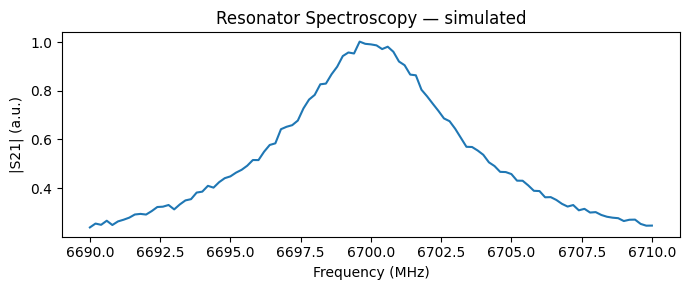

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 3))
plt.plot(result.x_axis, np.abs(result.raw_iq), lw=1.5)
plt.xlabel('Frequency (MHz)')
plt.ylabel('|S21| (a.u.)')
plt.title('Resonator Spectroscopy — simulated')
plt.tight_layout()
plt.show()

**Next:** [01_config_and_store.ipynb](01_config_and_store.ipynb) — managing experiment configuration and persisting calibration parameters.